# `pepsy.ham_tn` Clean Examples

This notebook is organized to provide:

1. A square-lattice baseline from `build_itf_lattice`.
2. An explicit `ints` construction path.
3. Mapping/reindex consistency checks.
4. A direct comparison to `quimb` `PEPO_nearest_neighbor`.
5. A final hexagonal geometry plot example.


In [1]:
from pathlib import Path
import sys

import numpy as np
import quimb.tensor as qtn
from quimb.operator.pepobuilder import PEPO_nearest_neighbor

repo_src = Path('/Users/rezah/Documents/py/src')
if str(repo_src) not in sys.path:
    sys.path.insert(0, str(repo_src))

import pepsy as py
tn_fidelity = py.core.tn_fidelity
core = py.core

print('py version:', getattr(py, '__version__', 'unknown'))


pepsy version: 0.1.1


## `ham_tn` Quick Usage (Read First)

### ITF convention used by `ham_tn`

`ham_tn` builds the transverse-field Ising model as:

`H = J * sum_<ij>(Z_i Z_j) + field * sum_i(X_i)`

There is **no implicit minus sign**. If you want
`H = -J0 * sum_<ij>(Z_i Z_j) - h * sum_i(X_i)`, pass `J=-J0` and `field=-h`.

Use one of these three entry points:

1. **One-call lattice build (recommended default)**

```python
H_mpo, H_pepo = pepsy.ham_tn.build_itf_lattice(
    L_x=Lx,
    L_y=Ly,
    lattice='square',
    cyclic=False,
    J=J,
    field=field,
)
```

2. **Named/custom lattice through a builder**

```python
builder = pepsy.ham_tn(L_x=Lx, L_y=Ly, max_bond=300, cutoff=1e-12, data_type='complex128')
H_mpo, H_pepo, edges = builder.build_itf(lattice='triangular', cyclic=False, J=J, field=field, return_edges=True)
```

3. **Explicit Hamiltonian terms (`ints`)**

```python
H_mpo = builder.build_mpo(ints, max_bond=300, cutoff=1e-12, data_type='complex128')
H_pepo = builder.mpo_to_pepo(H_mpo)
```

Use `plot_geometry=True, return_plot=True` in `build_itf` / `build_itf_lattice` to visualize lattice geometry and snake order.


In [2]:
import inspect

print('ham_tn constructor        :', inspect.signature(py.ham_tn))
print('build_itf_lattice         :', inspect.signature(py.ham_tn.build_itf_lattice))
print('build_itf                 :', inspect.signature(py.ham_tn.build_itf))
print('build_itf_from_edges      :', inspect.signature(py.ham_tn.build_itf_from_edges))
print('build_mpo                 :', inspect.signature(py.ham_tn.build_mpo))
print('mpo_to_pepo               :', inspect.signature(py.ham_tn.mpo_to_pepo))


ham_tn constructor        : (L_x, L_y, *, max_bond=256, cutoff=1e-12, data_type='float64', build_snake_maps=None)
build_itf_lattice         : (*, L_x, L_y, lattice='square', edges=None, cyclic=False, J=1.0, field=1.0, max_bond=256, cutoff=1e-12, data_type='float64', build_snake_maps=None, compress_each=True, cycle_peps=False, cycle_bond_dim=1, edge_kwargs=None, plot_geometry=False, plot_kwargs=None, return_plot=False, return_edges=False, return_builder=False)
build_itf                 : (self, lattice='square', *, edges=None, cyclic=False, J=1.0, field=1.0, max_bond=None, cutoff=None, data_type=None, compress_each=True, cycle_peps=False, cycle_bond_dim=1, edge_kwargs=None, plot_geometry=False, plot_kwargs=None, return_plot=False, return_edges=False)
build_itf_from_edges      : (self, edges, J=1.0, field=1.0, *, max_bond=None, cutoff=None, data_type=None, compress_each=True, cycle_peps=False, cycle_bond_dim=1)
build_mpo                 : (self, ints, *, phys_dim=2, max_bond=None, cutoff

In [3]:
optimizer = core.build_optimizer(progbar=False, directory='cash/', parallel=False)


In [ ]:
Lx = 4
Ly = 3
J = -1.0
field = -3.0
dtype = 'complex128'

print('Lx, Ly =', (Lx, Ly))
print('J, field =', (J, field))
print('ITF model = J * sum_<ij>(Z_i Z_j) + field * sum_i(X_i)')
if J < 0 and field < 0:
    print('Both ZZ and X terms have negative prefactors in this notebook setup.')


Lx, Ly = (4, 3)
J, field = (-1.0, -3.04)
ITF model = J * sum_<ij>(Z_i Z_j) + field * sum_i(X_i)
Both ZZ and X terms have negative prefactors in this notebook setup.


## A) Square Baseline (One-Call API)


In [5]:
lattice_name = "square"

H_mpo_sq, H_pepo_sq, edges_sq, builder_sq = py.ham_tn.build_itf_lattice(
    L_x=Lx,
    L_y=Ly,
    lattice=lattice_name,
    cyclic=False,
    J=J,
    field=field,
    max_bond=300,
    cutoff=1e-12,
    data_type=dtype,
    return_edges=True,
    return_builder=True,
)

edges_ref = tuple(qtn.edges_2d_square(Lx, Ly, cyclic=False))
print('lattice        :', lattice_name)
print('number of edges:', len(edges_sq))
print('MPO max bond   :', int(H_mpo_sq.max_bond()))
print('PEPO shape     :', (H_pepo_sq.Lx, H_pepo_sq.Ly))
print('edges match qtn:', tuple(edges_sq) == edges_ref)
print('map sample     :', {k: builder_sq.map[k] for k in range(min(8, builder_sq.L))})

assert tuple(edges_sq) == edges_ref


lattice        : square
number of edges: 17
MPO max bond   : 5
PEPO shape     : (4, 3)
edges match qtn: True
map sample     : {0: (0, 0), 1: (0, 1), 2: (0, 2), 3: (1, 2), 4: (1, 1), 5: (1, 0), 6: (2, 0), 7: (2, 1)}


## B) Explicit Build From `ints`


In [6]:
# Build the same square ITF Hamiltonian explicitly from term list `ints`.
builder_ints = py.ham_tn(
    L_x=Lx,
    L_y=Ly,
    max_bond=300,
    cutoff=1e-12,
    data_type=dtype,
)

Z_mat = np.asarray(py.pauli('Z'), dtype=dtype)
X_mat = np.asarray(py.pauli('X'), dtype=dtype)

ints = []
for x in range(Lx - 1):
    for y in range(Ly):
        ints.append((((x, y), (x + 1, y)), (Z_mat, Z_mat), J))
for x in range(Lx):
    for y in range(Ly - 1):
        ints.append((((x, y), (x, y + 1)), (Z_mat, Z_mat), J))
for x in range(Lx):
    for y in range(Ly):
        ints.append((((x, y),), (X_mat,), field))

H_mpo_ints = builder_ints.build_mpo(
    ints,
    max_bond=300,
    cutoff=1e-12,
    data_type=dtype,
)
H_pepo_ints = builder_ints.mpo_to_pepo(H_mpo_ints)

fid_mpo_ints_vs_sq = float(tn_fidelity(H_mpo_ints, H_mpo_sq, opt=optimizer))
fid_pepo_ints_vs_sq = float(tn_fidelity(H_pepo_ints, H_pepo_sq, opt=optimizer))

print('tn_fidelity(H_mpo_ints,  H_mpo_sq ) =', fid_mpo_ints_vs_sq)
print('tn_fidelity(H_pepo_ints, H_pepo_sq) =', fid_pepo_ints_vs_sq)

assert abs(1.0 - fid_mpo_ints_vs_sq) < 1e-8
assert abs(1.0 - fid_pepo_ints_vs_sq) < 1e-8


tn_fidelity(H_mpo_ints,  H_mpo_sq ) = 0.9999999999999997
tn_fidelity(H_pepo_ints, H_pepo_sq) = 1.0


## C) Custom Row-Major Mapping Checks


In [7]:
def row_major_maps(L_x, L_y):
    fwd = {i: (i // L_y, i % L_y) for i in range(L_x * L_y)}
    inv = {coord: idx for idx, coord in fwd.items()}
    return fwd, inv

builder_row = py.ham_tn(
    L_x=Lx,
    L_y=Ly,
    max_bond=300,
    cutoff=1e-12,
    data_type=dtype,
    build_snake_maps=row_major_maps,
)

expected_row_major = {i: (i // Ly, i % Ly) for i in range(Lx * Ly)}
assert builder_row.map == expected_row_major
assert all(builder_row.map_inv[builder_row.map[i]] == i for i in range(builder_row.L))
assert all(builder_row.map[builder_row.map_inv[(x, y)]] == (x, y) for x in range(Lx) for y in range(Ly))

diff_idx = [i for i in range(builder_sq.L) if builder_sq.map[i] != builder_row.map[i]]
print('row-major checks passed.')
print('num chain positions different from default snake:', len(diff_idx))
if diff_idx:
    j = diff_idx[0]
    print(f'first differing index {j}: snake={builder_sq.map[j]} row-major={builder_row.map[j]}')


row-major checks passed.
num chain positions different from default snake: 4
first differing index 3: snake=(1, 2) row-major=(1, 0)


## D) PEPO 2D <-> 1D Reindex Consistency


In [8]:
print('MPO outer inds sample :', sorted(H_mpo_sq.outer_inds())[:8])
print('PEPO outer inds sample:', sorted(H_pepo_sq.outer_inds())[:8])

reindex_kb = {}
for (x, y), chain_idx in builder_sq.map_inv.items():
    reindex_kb[f'k{x},{y}'] = f'k{chain_idx}'
    reindex_kb[f'b{x},{y}'] = f'b{chain_idx}'

H_pepo_1d = H_pepo_sq.copy()
H_pepo_1d.reindex_(reindex_kb)
print('Reindexed PEPO outer inds sample:', sorted(H_pepo_1d.outer_inds())[:8])

fid_mpo_vs_pepo1d = float(tn_fidelity(H_pepo_1d, H_mpo_sq, opt=optimizer))
print('tn_fidelity(H_pepo_1d, H_mpo_sq) =', fid_mpo_vs_pepo1d)

inv_reindex_kb = {v: k for k, v in reindex_kb.items()}
H_pepo_back = H_pepo_1d.copy()
H_pepo_back.reindex_(inv_reindex_kb)
fid_back = float(tn_fidelity(H_pepo_back, H_pepo_sq, opt=optimizer))
print('tn_fidelity(H_pepo_back, H_pepo_sq) =', fid_back)

assert abs(1.0 - fid_mpo_vs_pepo1d) < 1e-8
assert abs(1.0 - fid_back) < 1e-8


MPO outer inds sample : ['b0', 'b1', 'b10', 'b11', 'b2', 'b3', 'b4', 'b5']
PEPO outer inds sample: ['b0,0', 'b0,1', 'b0,2', 'b1,0', 'b1,1', 'b1,2', 'b2,0', 'b2,1']
Reindexed PEPO outer inds sample: ['b0', 'b1', 'b10', 'b11', 'b2', 'b3', 'b4', 'b5']
tn_fidelity(H_pepo_1d, H_mpo_sq) = 1.0
tn_fidelity(H_pepo_back, H_pepo_sq) = 1.0


## E) `pepsy` Square PEPO vs `quimb` `PEPO_nearest_neighbor`


In [9]:
H_pepo_quimb = PEPO_nearest_neighbor(
    A=J * Z_mat,
    B=Z_mat,
    C=field * X_mat,
    Lx=Lx,
    Ly=Ly,
    cyclic=False,
    dtype=dtype,
)

print('quimb PEPO shape:', (H_pepo_quimb.Lx, H_pepo_quimb.Ly))
print('ours  outer inds sample:', sorted(H_pepo_sq.outer_inds())[:8])
print('quimb outer inds sample:', sorted(H_pepo_quimb.outer_inds())[:8])

fid_ours_vs_quimb = float(tn_fidelity(H_pepo_sq, H_pepo_quimb, opt=optimizer))
print('tn_fidelity(H_pepo_sq, H_pepo_quimb) =', fid_ours_vs_quimb)
print('abs(1 - fidelity) =', abs(1.0 - fid_ours_vs_quimb))

assert abs(1.0 - fid_ours_vs_quimb) < 1e-8


quimb PEPO shape: (4, 3)
ours  outer inds sample: ['b0,0', 'b0,1', 'b0,2', 'b1,0', 'b1,1', 'b1,2', 'b2,0', 'b2,1']
quimb outer inds sample: ['b0,0', 'b0,1', 'b0,2', 'b1,0', 'b1,1', 'b1,2', 'b2,0', 'b2,1']


tn_fidelity(H_pepo_sq, H_pepo_quimb) = 1.0000000000000007
abs(1 - fidelity) = 6.661338147750939e-16


In [10]:
# DMRG ground-state search on the square-lattice MPO built above.
dmrg = qtn.DMRG2(
    H_mpo_sq,
    bond_dims=[16, 32, 64],
    cutoffs=[1e-8, 1e-10, 1e-12],
)

converged = dmrg.solve(
    tol=1e-7,
    max_sweeps=6,
    verbosity=0,
)

E0 = dmrg.energy
print('DMRG converged :', bool(converged))
print('DMRG sweeps    :', len(dmrg.energies))
print('DMRG E0 (real) :', float(np.real(E0)))
print('DMRG E0 imag   :', float(np.imag(E0)))
print('GS MPS max bond:', dmrg.state.max_bond())


DMRG converged : True
DMRG sweeps    : 3
DMRG E0 (real) : -37.9905298072981
DMRG E0 imag   : -5.111120270107956e-15
GS MPS max bond: 29


## F) Hexagonal Geometry Plot (Final Cell)


/Users/rezah/Documents/pepsy/src/pepsy/ham.py:140: UserWarning: Detected sublattice-labelled sites (e.g. kagome/hexagonal). Remapping to rectangular grid with shape (4, 6) for MPO/PEPO build.
  out = builder.build_itf(


lattice        : hexagonal
number of edges: 29
MPO max bond   : 6
PEPO shape     : (4, 6)


<Axes: title={'center': 'Hexagonal Lattice + Snake MPS Path'}, xlabel='x', ylabel='y'>

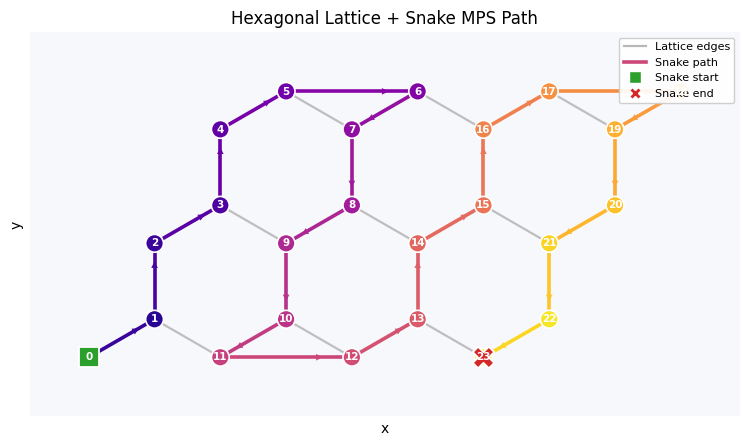

In [11]:
lattice = "hexagonal"  # try: "square", "triangular", "hexagonal", "kagome"

H_mpo, H_pepo, edges, ax = py.ham_tn.build_itf_lattice(
    L_x=Lx,
    L_y=Ly,
    lattice=lattice,
    cyclic=False,
    J=J,
    field=field,
    max_bond=300,
    cutoff=1e-12,
    data_type="complex128",
    plot_geometry=True,
    return_plot=True,
    return_edges=True,
)
print('lattice        :', lattice)
print('number of edges:', len(edges))
print('MPO max bond   :', H_mpo.max_bond())
print('PEPO shape     :', (H_pepo.Lx, H_pepo.Ly))
ax.figure.tight_layout()
ax
